In [6]:
    "import plotly.graph_objects as go\n",
    "from IPython.display import HTML, display\n",
    "fig.show()\n",
    display(HTML(fig.to_html(include_plotlyjs='cdn')))\n",
{
    "cells": [
        {
            "cell_type": "code",
            "id": "#VSC-cbba0f14",
            "metadata": {
                "language": "python"
            },
            "source": [
                "import numpy as np",
                "import matplotlib.pyplot as plt",
                "from math import comb",
                "from itertools import combinations",
                "from scipy.sparse import coo_matrix",
                "from scipy.sparse.linalg import eigsh",
                "from scipy.linalg import svdvals",
                "",
                "try:",
                "    from numba import njit",
                "except Exception:",
                "    def njit(*args, **kwargs):",
                "        if args and len(args) == 1 and callable(args[0]) and not kwargs:",
                "            return args[0]",
                "",
                "        def decorator(func):",
                "            return func",
                "",
                "        return decorator",
                "",
                "",
                "@njit(cache=True)",
                "def _build_cut_map_numba(states, L, ell):",
                "    dim = states.shape[0]",
                "    row_a = np.empty(dim, dtype=np.int32)",
                "    row_b = np.empty(dim, dtype=np.int32)",
                "    left_shift = L - ell",
                "    left_mask = (np.uint64(1) << np.uint64(left_shift)) - np.uint64(1)",
                "    right_mask = (np.uint64(1) << np.uint64(ell)) - np.uint64(1)",
                "",
                "    for i in range(dim):",
                "        state = states[i]",
                "        row_a[i] = int((state >> np.uint64(left_shift)) & left_mask)",
                "        row_b[i] = int(state & right_mask)",
                "",
                "    return row_a, row_b",
                "",
                "",
                "@njit(cache=True)",
                "def _build_hamiltonian_triplets(states, index_map, L, pairs1, pairs2, J1xy, J1z, J2xy, J2z, kind_flag):",
                "    dim = states.shape[0]",
                "    n1 = pairs1.shape[0]",
                "    n2 = pairs2.shape[0]",
                "    if kind_flag == 0:",
                "        max_nnz = dim + dim * n1",
                "    else:",
                "        max_nnz = dim + dim * (n1 + n2)",
                "",
                "    rows = np.empty(max_nnz, dtype=np.int32)",
                "    cols = np.empty(max_nnz, dtype=np.int32)",
                "    vals = np.empty(max_nnz, dtype=np.float64)",
                "    diag = np.zeros(dim, dtype=np.float64)",
                "    one = np.uint64(1)",
                "    cursor = 0",
                "",
                "    for i in range(dim):",
                "        state = states[i]",
                "",
                "        for p in range(n1):",
                "            a = pairs1[p, 0]",
                "            b = pairs1[p, 1]",
                "            pa = np.uint64(L - 1 - a)",
                "            pb = np.uint64(L - 1 - b)",
                "            bit_a = (state >> pa) & one",
                "            bit_b = (state >> pb) & one",
                "            if bit_a == bit_b:",
                "                diag[i] += J1z / 4.0",
                "            else:",
                "                diag[i] -= J1z / 4.0",
                "                if J1xy != 0.0:",
                "                    flipped = state ^ ((one << pa) | (one << pb))",
                "                    j = index_map[np.int64(flipped)]",
                "                    rows[cursor] = i",
                "                    cols[cursor] = j",
                "                    vals[cursor] = J1xy / 2.0",
                "                    cursor += 1",
                "",
                "        if kind_flag == 1:",
                "            for p in range(n2):",
                "                a = pairs2[p, 0]",
                "                b = pairs2[p, 1]",
                "                pa = np.uint64(L - 1 - a)",
                "                pb = np.uint64(L - 1 - b)",
                "                bit_a = (state >> pa) & one",
                "                bit_b = (state >> pb) & one",
                "                if bit_a == bit_b:",
                "                    diag[i] += J2z / 4.0",
                "                else:",
                "                    diag[i] -= J2z / 4.0",
                "                    if J2xy != 0.0:",
                "                        flipped = state ^ ((one << pa) | (one << pb))",
                "                        j = index_map[np.int64(flipped)]",
                "                        rows[cursor] = i",
                "                        cols[cursor] = j",
                "                        vals[cursor] = J2xy / 2.0",
                "                        cursor += 1",
                "",
                "    for i in range(dim):",
                "        rows[cursor] = i",
                "        cols[cursor] = i",
                "        vals[cursor] = diag[i]",
                "        cursor += 1",
                "",
                "    return rows[:cursor], cols[:cursor], vals[:cursor]",
                "",
                "",
                "class FastXXZChain:",
                "    \"\"\"Optimized fixed-Nup XXZ chain with cached basis, Hamiltonian, and entropy maps.\"\"\"",
                "",
                "    def __init__(self, L, Nup, periodic=True, J1xy=1.0, J1z=0.5, J2xy=0.0, J2z=0.0):",
                "        self.L = int(L)",
                "        self.Nup = int(Nup)",
                "        self.periodic = bool(periodic)",
                "        self.J1xy = float(J1xy)",
                "        self.J1z = float(J1z)",
                "        self.J2xy = float(J2xy)",
                "        self.J2z = float(J2z)",
                "",
                "        self.states = self._build_basis_states()",
                "        self.index_map = self._build_index_map()",
                "        self.pairs1 = np.asarray(self._pairs(1), dtype=np.int32)",
                "        self.pairs2 = np.asarray(self._pairs(2), dtype=np.int32)",
                "        self._entropy_cache = {}",
                "",
                "    def _build_basis_states(self):",
                "        states = []",
                "        for positions in combinations(range(self.L), self.Nup):",
                "            value = 0",
                "            for site in positions:",
                "                value |= 1 << (self.L - 1 - site)",
                "            states.append(value)",
                "        return np.asarray(states, dtype=np.uint64)",
                "",
                "    def _build_index_map(self):",
                "        size = 1 << self.L",
                "        index_map = -np.ones(size, dtype=np.int32)",
                "        for i, state in enumerate(self.states):",
                "            index_map[int(state)] = i",
                "        return index_map",
                "",
                "    def _pairs(self, order):",
                "        if order == 1:",
                "            if self.periodic:",
                "                return [(i, (i + 1) % self.L) for i in range(self.L)]",
                "            return [(i, i + 1) for i in range(self.L - 1)]",
                "        if order == 2:",
                "            if self.periodic:",
                "                return [(i, (i + 2) % self.L) for i in range(self.L)]",
                "            return [(i, i + 2) for i in range(self.L - 2)]",
                "        raise ValueError('order must be 1 or 2')",
                "",
                "    def hilbert_dimension(self):",
                "        return int(self.states.size)",
                "",
                "    def build_hamiltonian(self, kind='nnn'):",
                "        if kind not in {'nn', 'nnn'}:",
                "            raise ValueError(\"kind must be 'nn' or 'nnn'.\")",
                "",
                "        kind_flag = 0 if kind == 'nn' else 1",
                "        rows, cols, vals = _build_hamiltonian_triplets(",
                "            self.states,",
                "            self.index_map,",
                "            self.L,",
                "            self.pairs1,",
                "            self.pairs2,",
                "            self.J1xy,",
                "            self.J1z,",
                "            self.J2xy,",
                "            self.J2z,",
                "            kind_flag,",
                "        )",
                "        dim = self.hilbert_dimension()",
                "        return coo_matrix((vals, (rows, cols)), shape=(dim, dim)).tocsr()",
                "",
                "    def ground_state(self, kind='nnn'):",
                "        H = self.build_hamiltonian(kind=kind)",
                "        if H.shape[0] == 1:",
                "            return float(H[0, 0]), np.array([1.0], dtype=float)",
                "        eigvals, eigvecs = eigsh(H, k=1, which='SA', tol=1e-12, maxiter=100000)",
                "        return float(eigvals[0]), eigvecs[:, 0]",
                "",
                "    def _cut_map(self, ell):",
                "        if ell in self._entropy_cache:",
                "            return self._entropy_cache[ell]",
                "",
                "        row_a, row_b = _build_cut_map_numba(self.states, self.L, ell)",
                "        mapping = {",
                "            'rowA': row_a,",
                "            'rowB': row_b,",
                "            'dimA': 1 << ell,",
                "            'dimB': 1 << (self.L - ell),",
                "        }",
                "        self._entropy_cache[ell] = mapping",
                "        return mapping",
                "",
                "    def entropy_curve(self, kind='nnn', blocks=None):",
                "        ground_energy, sector_state = self.ground_state(kind=kind)",
                "        if blocks is None:",
                "            blocks = range(1, self.L)",
                "        block_list = sorted({int(block) for block in blocks if 0 < block < self.L})",
                "",
                "        entropies = np.zeros(len(block_list), dtype=float)",
                "        for i, ell in enumerate(block_list):",
                "            data = self._cut_map(ell)",
                "            psi_matrix = np.zeros((data['dimA'], data['dimB']), dtype=complex)",
                "            psi_matrix[data['rowA'], data['rowB']] = sector_state",
                "            svals = svdvals(psi_matrix)",
                "            probs = svals**2",
                "            probs = probs[probs > 1e-14]",
                "            entropies[i] = float(-np.sum(probs * np.log(probs)))",
                "",
                "        block_sizes = np.asarray(block_list, dtype=int)",
                "        upper_bound = np.log(2.0) * np.minimum(block_sizes, self.L - block_sizes)",
                "        return block_sizes, entropies, upper_bound, ground_energy",
                "",
                "    def plot_entropy(self, kind='nnn', blocks=None, title=None):",
                "        block_sizes, entropies, upper_bound, ground_energy = self.entropy_curve(kind=kind, blocks=blocks)",
                "        fig, ax = plt.subplots(figsize=(8, 5))",
                "        ax.plot(block_sizes, entropies, marker='o', linewidth=2, label='Entropy')",
                "        ax.plot(block_sizes, upper_bound, '--', linewidth=2, label='Upper Bound')",
                "        ax.set_xlabel('Block size l')",
                "        ax.set_ylabel('S(l)')",
                "        ax.set_title(title or f'Entanglement Entropy (E0 = {ground_energy:.6f})')",
                "        ax.grid(True, alpha=0.3)",
                "        ax.legend()",
                "        plt.tight_layout()",
                "        plt.show()",
                "",
                "",
                "def half_filling_dimension(L):",
                "    return comb(L, L // 2)",
                "",
                "",
                "def recommended_max_L(limit_dim=200000):",
                "    best = 0",
                "    for L in range(2, 40, 2):",
                "        if half_filling_dimension(L) <= limit_dim:",
                "            best = L",
                "    return best",
                ""
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-741977a6",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Entanglement entropy vs J2, with one curve for each even L = 2..20.",
                "# The y-value is the half-chain entropy S(L/2) at half filling.",
                "L_values = range(2, 15, 2)",
                "J2_scan = np.round(np.arange(0.0, 1.4 + 1e-9, 0.01), 15)",
                "",
                "fig, ax = plt.subplots(figsize=(8, 5))",
                "for chain_length in L_values:",
                "    print(f\"Processing L={chain_length}\")",
                "    nup = (chain_length // 2 )",
                "    chain = FastXXZChain(",
                "        L=chain_length,",
                "        Nup=nup,",
                "        periodic=True,",
                "        J1xy=1.0,",
                "        J1z=0.5,",
                "        J2xy=0.0,",
                "        J2z=0.0,",
                "    )",
                "",
                "    entropy_vs_J2 = []",
                "    mid_block = chain_length // 2",
                "    for J2_val in J2_scan:",
                "        chain.J2xy = float(J2_val)",
                "        blocks, entropies, upper_bound, energy = chain.entropy_curve(kind=\"nnn\", blocks=[mid_block])",
                "        entropy_vs_J2.append(entropies[0])",
                "",
                "    ax.plot(J2_scan, entropy_vs_J2, linewidth=1, label=f\"L={chain_length}\")",
                "",
                "ax.set_xlabel(\"J2\")",
                "ax.set_ylabel(\"Half-chain entanglement entropy\")",
                "ax.set_title(\"Half-chain entanglement entropy vs J2 for even L = 2..20\")",
                "ax.grid(True, alpha=0.3)",
                "ax.legend(ncol=2, fontsize=8)",
                "plt.tight_layout()",
                "plt.show()",
                ""
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-03b503f9",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# Entanglement entropy vs J2, sweeping the flip-flop and Ising next-nearest-neighbour terms together.",
                "# Here the same J2 value is applied to both J2xy and J2z at each step.",
                "L_values = range(2, 15, 2)",
                "J2_scan = np.round(np.arange(0.0, 1.4 + 1e-9, 0.01), 15)",
                "",
                "fig, ax = plt.subplots(figsize=(8, 5))",
                "for chain_length in L_values:",
                "    print(f\"Processing L={chain_length}\")",
                "    nup = chain_length // 2",
                "    chain = FastXXZChain(",
                "        L=chain_length,",
                "        Nup=nup,",
                "        periodic=True,",
                "        J1xy=1.0,",
                "        J1z=0.5,",
                "        J2xy=0.0,",
                "        J2z=0.0,",
                "    )",
                "",
                "    entropy_vs_J2 = []",
                "    mid_block = chain_length // 2",
                "    for J2_val in J2_scan:",
                "        chain.J2xy = float(J2_val)",
                "        chain.J2z = float(J2_val)",
                "        _, entropies, _, _ = chain.entropy_curve(kind=\"nnn\", blocks=[mid_block])",
                "        entropy_vs_J2.append(entropies[0])",
                "",
                "    ax.plot(J2_scan, entropy_vs_J2, linewidth=1, label=f\"L={chain_length}\")",
                "",
                "ax.set_xlabel(\"J2\")",
                "ax.set_ylabel(\"Half-chain entanglement entropy\")",
                "ax.set_title(\"Half-chain entanglement entropy vs J2 with J2xy = J2z\")",
                "ax.grid(True, alpha=0.3)",
                "ax.legend(ncol=2, fontsize=8)",
                "plt.tight_layout()",
                "plt.show()",
                ""
            ]
        },
        {
            "cell_type": "code",
            "id": "#VSC-5ec6fd62",
            "metadata": {
                "language": "python"
            },
            "source": [
                "# 3D sweep over the Ising and flip-flop next-nearest-neighbour couplings.",
                "# This plots the half-chain entropy as an interactive surface over (J2xy, J2z).",
                "import plotly.graph_objects as go",
                "from IPython.display import HTML, display",
                "",
                "L = 10",
                "chain = FastXXZChain(",
                "    L=L,",
                "    Nup=L // 2,",
                "    periodic=True,",
                "    J1xy=1.0,",
                "    J1z=0.5,",
                "    J2xy=0.0,",
                "    J2z=0.0,",
                ")",
                "",
                "J2xy_values = np.round(np.linspace(0.0, 1.4, 9), 3)",
                "J2z_values = np.round(np.linspace(0.0, 1.4, 9), 3)",
                "S_grid = np.zeros((len(J2z_values), len(J2xy_values)), dtype=float)",
                "block = L // 2",
                "",
                "for i, J2z in enumerate(J2z_values):",
                "    for j, J2xy in enumerate(J2xy_values):",
                "        chain.J2xy = float(J2xy)",
                "        chain.J2z = float(J2z)",
                "        _, entropies, _, _ = chain.entropy_curve(kind=\"nnn\", blocks=[block])",
                "        S_grid[i, j] = entropies[0]",
                "",
                "fig = go.Figure(",
                "    data=[",
                "        go.Surface(",
                "            x=J2xy_values,",
                "            y=J2z_values,",
                "            z=S_grid,",
                "            colorscale='Viridis',",
                "            colorbar=dict(title='Entropy'),",
                "        )",
                "    ]",
                ")",
                "fig.update_layout(",
                "    title=f'Half-chain entanglement entropy over (J2xy, J2z) at L={L}',",
                "    scene=dict(",
                "        xaxis_title='J2xy',",
                "        yaxis_title='J2z',",
                "        zaxis_title='Half-chain entropy',",
                "        camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),",
                "    ),",
                "    margin=dict(l=0, r=0, b=0, t=40),",
                ")",
                "display(HTML(fig.to_html(include_plotlyjs='cdn')))",
                ""
            ]
        }
    ]
}

IndentationError: unexpected indent (2304057037.py, line 1)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from math import comb
from itertools import combinations
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import eigsh
from scipy.linalg import svdvals

try:
    from numba import njit
except Exception:
    def njit(*args, **kwargs):
        if args and len(args) == 1 and callable(args[0]) and not kwargs:
            return args[0]

        def decorator(func):
            return func

        return decorator


@njit(cache=True)
def _build_cut_map_numba(states, L, ell):
    dim = states.shape[0]
    row_a = np.empty(dim, dtype=np.int32)
    row_b = np.empty(dim, dtype=np.int32)
    left_shift = L - ell
    left_mask = (np.uint64(1) << np.uint64(left_shift)) - np.uint64(1)
    right_mask = (np.uint64(1) << np.uint64(ell)) - np.uint64(1)

    for i in range(dim):
        state = states[i]
        row_a[i] = int((state >> np.uint64(left_shift)) & left_mask)
        row_b[i] = int(state & right_mask)

    return row_a, row_b


@njit(cache=True)
def _build_hamiltonian_triplets(states, index_map, L, pairs1, pairs2, J1xy, J1z, J2xy, J2z, kind_flag):
    dim = states.shape[0]
    n1 = pairs1.shape[0]
    n2 = pairs2.shape[0]
    if kind_flag == 0:
        max_nnz = dim + dim * n1
    else:
        max_nnz = dim + dim * (n1 + n2)

    rows = np.empty(max_nnz, dtype=np.int32)
    cols = np.empty(max_nnz, dtype=np.int32)
    vals = np.empty(max_nnz, dtype=np.float64)
    diag = np.zeros(dim, dtype=np.float64)
    one = np.uint64(1)
    cursor = 0

    for i in range(dim):
        state = states[i]

        for p in range(n1):
            a = pairs1[p, 0]
            b = pairs1[p, 1]
            pa = np.uint64(L - 1 - a)
            pb = np.uint64(L - 1 - b)
            bit_a = (state >> pa) & one
            bit_b = (state >> pb) & one
            if bit_a == bit_b:
                diag[i] += J1z / 4.0
            else:
                diag[i] -= J1z / 4.0
                if J1xy != 0.0:
                    flipped = state ^ ((one << pa) | (one << pb))
                    j = index_map[np.int64(flipped)]
                    rows[cursor] = i
                    cols[cursor] = j
                    vals[cursor] = J1xy / 2.0
                    cursor += 1

        if kind_flag == 1:
            for p in range(n2):
                a = pairs2[p, 0]
                b = pairs2[p, 1]
                pa = np.uint64(L - 1 - a)
                pb = np.uint64(L - 1 - b)
                bit_a = (state >> pa) & one
                bit_b = (state >> pb) & one
                if bit_a == bit_b:
                    diag[i] += J2z / 4.0
                else:
                    diag[i] -= J2z / 4.0
                    if J2xy != 0.0:
                        flipped = state ^ ((one << pa) | (one << pb))
                        j = index_map[np.int64(flipped)]
                        rows[cursor] = i
                        cols[cursor] = j
                        vals[cursor] = J2xy / 2.0
                        cursor += 1

    for i in range(dim):
        rows[cursor] = i
        cols[cursor] = i
        vals[cursor] = diag[i]
        cursor += 1

    return rows[:cursor], cols[:cursor], vals[:cursor]


class FastXXZChain:
    """Optimized fixed-Nup XXZ chain with cached basis, Hamiltonian, and entropy maps."""

    def __init__(self, L, Nup, periodic=True, J1xy=1.0, J1z=0.5, J2xy=0.0, J2z=0.0):
        self.L = int(L)
        self.Nup = int(Nup)
        self.periodic = bool(periodic)
        self.J1xy = float(J1xy)
        self.J1z = float(J1z)
        self.J2xy = float(J2xy)
        self.J2z = float(J2z)

        self.states = self._build_basis_states()
        self.index_map = self._build_index_map()
        self.pairs1 = np.asarray(self._pairs(1), dtype=np.int32)
        self.pairs2 = np.asarray(self._pairs(2), dtype=np.int32)
        self._entropy_cache = {}

    def _build_basis_states(self):
        states = []
        for positions in combinations(range(self.L), self.Nup):
            value = 0
            for site in positions:
                value |= 1 << (self.L - 1 - site)
            states.append(value)
        return np.asarray(states, dtype=np.uint64)

    def _build_index_map(self):
        size = 1 << self.L
        index_map = -np.ones(size, dtype=np.int32)
        for i, state in enumerate(self.states):
            index_map[int(state)] = i
        return index_map

    def _pairs(self, order):
        if order == 1:
            if self.periodic:
                return [(i, (i + 1) % self.L) for i in range(self.L)]
            return [(i, i + 1) for i in range(self.L - 1)]
        if order == 2:
            if self.periodic:
                return [(i, (i + 2) % self.L) for i in range(self.L)]
            return [(i, i + 2) for i in range(self.L - 2)]
        raise ValueError('order must be 1 or 2')

    def hilbert_dimension(self):
        return int(self.states.size)

    def build_hamiltonian(self, kind='nnn'):
        if kind not in {'nn', 'nnn'}:
            raise ValueError("kind must be 'nn' or 'nnn'.")

        kind_flag = 0 if kind == 'nn' else 1
        rows, cols, vals = _build_hamiltonian_triplets(
            self.states,
            self.index_map,
            self.L,
            self.pairs1,
            self.pairs2,
            self.J1xy,
            self.J1z,
            self.J2xy,
            self.J2z,
            kind_flag,
        )
        dim = self.hilbert_dimension()
        return coo_matrix((vals, (rows, cols)), shape=(dim, dim)).tocsr()

    def ground_state(self, kind='nnn'):
        H = self.build_hamiltonian(kind=kind)
        if H.shape[0] == 1:
            return float(H[0, 0]), np.array([1.0], dtype=float)
        eigvals, eigvecs = eigsh(H, k=1, which='SA', tol=1e-12, maxiter=100000)
        return float(eigvals[0]), eigvecs[:, 0]

    def _cut_map(self, ell):
        if ell in self._entropy_cache:
            return self._entropy_cache[ell]

        row_a, row_b = _build_cut_map_numba(self.states, self.L, ell)
        mapping = {
            'rowA': row_a,
            'rowB': row_b,
            'dimA': 1 << ell,
            'dimB': 1 << (self.L - ell),
        }
        self._entropy_cache[ell] = mapping
        return mapping

    def entropy_curve(self, kind='nnn', blocks=None):
        ground_energy, sector_state = self.ground_state(kind=kind)
        if blocks is None:
            blocks = range(1, self.L)
        block_list = sorted({int(block) for block in blocks if 0 < block < self.L})

        entropies = np.zeros(len(block_list), dtype=float)
        for i, ell in enumerate(block_list):
            data = self._cut_map(ell)
            psi_matrix = np.zeros((data['dimA'], data['dimB']), dtype=complex)
            psi_matrix[data['rowA'], data['rowB']] = sector_state
            svals = svdvals(psi_matrix)
            probs = svals**2
            probs = probs[probs > 1e-14]
            entropies[i] = float(-np.sum(probs * np.log(probs)))

        block_sizes = np.asarray(block_list, dtype=int)
        upper_bound = np.log(2.0) * np.minimum(block_sizes, self.L - block_sizes)
        return block_sizes, entropies, upper_bound, ground_energy

    def plot_entropy(self, kind='nnn', blocks=None, title=None):
        block_sizes, entropies, upper_bound, ground_energy = self.entropy_curve(kind=kind, blocks=blocks)
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(block_sizes, entropies, marker='o', linewidth=2, label='Entropy')
        ax.plot(block_sizes, upper_bound, '--', linewidth=2, label='Upper Bound')
        ax.set_xlabel('Block size l')
        ax.set_ylabel('S(l)')
        ax.set_title(title or f'Entanglement Entropy (E0 = {ground_energy:.6f})')
        ax.grid(True, alpha=0.3)
        ax.legend()
        plt.tight_layout()
        plt.show()


def half_filling_dimension(L):
    return comb(L, L // 2)


def recommended_max_L(limit_dim=200000):
    best = 0
    for L in range(2, 40, 2):
        if half_filling_dimension(L) <= limit_dim:
            best = L
    return best


Processing L=2
Processing L=4
Processing L=6
Processing L=8
Processing L=10
Processing L=12
Processing L=14


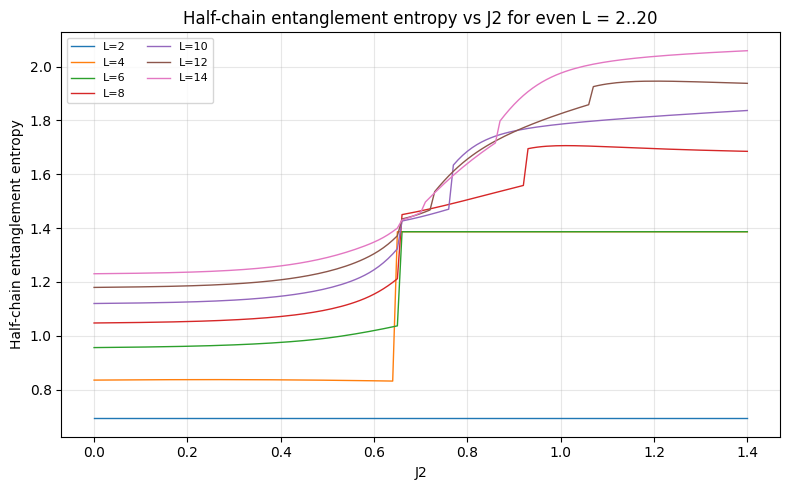

In [ ]:
# Entanglement entropy vs J2, with one curve for each even L = 2..20.
# The y-value is the half-chain entropy S(L/2) at half filling.
L_values = range(2, 15, 2)
J2_scan = np.round(np.arange(0.0, 1.4 + 1e-9, 0.01), 15)

fig, ax = plt.subplots(figsize=(8, 5))
for chain_length in L_values:
    print(f"Processing L={chain_length}")
    nup = (chain_length // 2 )
    chain = FastXXZChain(
        L=chain_length,
        Nup=nup,
        periodic=True,
        J1xy=1.0,
        J1z=0.5,
        J2xy=0.0,
        J2z=0.0,
    )

    entropy_vs_J2 = []
    mid_block = chain_length // 2
    for J2_val in J2_scan:
        chain.J2xy = float(J2_val)
        blocks, entropies, upper_bound, energy = chain.entropy_curve(kind="nnn", blocks=[mid_block])
        entropy_vs_J2.append(entropies[0])

    ax.plot(J2_scan, entropy_vs_J2, linewidth=1, label=f"L={chain_length}")

ax.set_xlabel("J2")
ax.set_ylabel("Half-chain entanglement entropy")
ax.set_title("Half-chain entanglement entropy vs J2 for even L = 2..20")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


Processing L=2
Processing L=4
Processing L=6
Processing L=8
Processing L=10
Processing L=12
Processing L=14


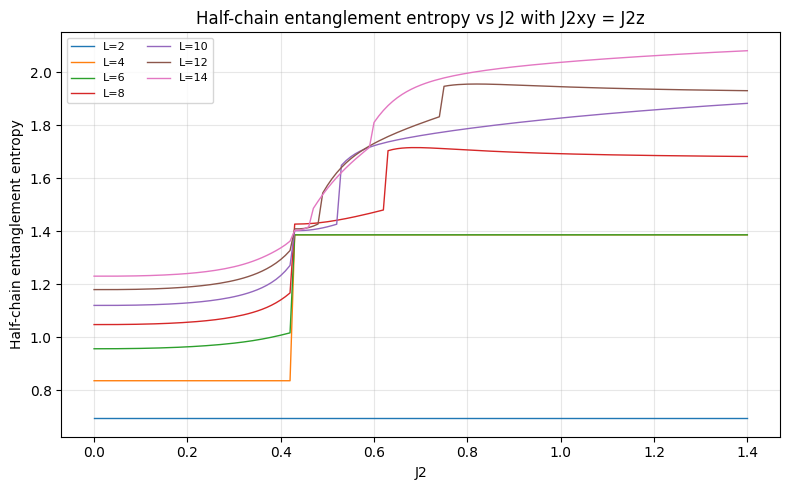

In [ ]:
# Entanglement entropy vs J2, sweeping the flip-flop and Ising next-nearest-neighbour terms together.
# Here the same J2 value is applied to both J2xy and J2z at each step.
L_values = range(2, 15, 2)
J2_scan = np.round(np.arange(0.0, 1.4 + 1e-9, 0.01), 15)

fig, ax = plt.subplots(figsize=(8, 5))
for chain_length in L_values:
    print(f"Processing L={chain_length}")
    nup = chain_length // 2
    chain = FastXXZChain(
        L=chain_length,
        Nup=nup,
        periodic=True,
        J1xy=1.0,
        J1z=0.5,
        J2xy=0.0,
        J2z=0.0,
    )

    entropy_vs_J2 = []
    mid_block = chain_length // 2
    for J2_val in J2_scan:
        chain.J2xy = float(J2_val)
        chain.J2z = float(J2_val)
        _, entropies, _, _ = chain.entropy_curve(kind="nnn", blocks=[mid_block])
        entropy_vs_J2.append(entropies[0])

    ax.plot(J2_scan, entropy_vs_J2, linewidth=1, label=f"L={chain_length}")

ax.set_xlabel("J2")
ax.set_ylabel("Half-chain entanglement entropy")
ax.set_title("Half-chain entanglement entropy vs J2 with J2xy = J2z")
ax.grid(True, alpha=0.3)
ax.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()


In [16]:
# Interactive 3D surface for rotating the entropy landscape over (J2xy, J2z).
from IPython.display import HTML, display
import plotly.graph_objects as go

L = 10
chain = FastXXZChain(
    L=L,
    Nup=L // 2,
    periodic=True,
    J1xy=1.0,
    J1z=0.5,
    J2xy=0.0,
    J2z=0.0,
)

J2xy_values = np.round(np.linspace(-4, 4.0, 19), 3)
J2z_values = np.round(np.linspace(-4.0, 4.0, 19), 3)
S_grid = np.zeros((len(J2z_values), len(J2xy_values)), dtype=float)
block = L // 2

for i, J2z in enumerate(J2z_values):
    for j, J2xy in enumerate(J2xy_values):
        chain.J2xy = float(J2xy)
        chain.J2z = float(J2z)
        _, entropies, _, _ = chain.entropy_curve(kind="nnn", blocks=[block])
        S_grid[i, j] = entropies[0]

fig = go.Figure(data=[go.Surface(x=J2xy_values, y=J2z_values, z=S_grid, colorscale='Viridis')])
fig.update_layout(
    title=f'Interactive half-chain entropy surface at L={L}',
    scene=dict(
        xaxis_title='J2xy',
        yaxis_title='J2z',
        zaxis_title='Half-chain entropy',
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))


In [17]:
# Interactive 3D surface for rotating the entropy landscape over (J1xy, J1z) with J2 fixed to zero.
from IPython.display import HTML, display
import plotly.graph_objects as go

L = 14
chain = FastXXZChain(
    L=L,
    Nup=L // 2,
    periodic=True,
    J1xy=0.0,
    J1z=0.0,
    J2xy=0.0,
    J2z=0.0,
)

J1xy_values = np.round(np.linspace(-4.0, 4.0, 19), 3)
J1z_values = np.round(np.linspace(-4.0, 4.0, 19), 3)
S_grid = np.zeros((len(J1z_values), len(J1xy_values)), dtype=float)
block = L // 2

for i, J1z in enumerate(J1z_values):
    for j, J1xy in enumerate(J1xy_values):
        if abs(J1xy) < 1e-12 and abs(J1z) < 1e-12:
            S_grid[i, j] = np.nan
            continue

        chain.J1xy = float(J1xy)
        chain.J1z = float(J1z)
        chain.J2xy = 0.0
        chain.J2z = 0.0
        _, entropies, _, _ = chain.entropy_curve(kind="nnn", blocks=[block])
        S_grid[i, j] = entropies[0]

fig = go.Figure(data=[go.Surface(x=J1xy_values, y=J1z_values, z=S_grid, colorscale='Viridis')])
fig.update_layout(
    title=f'Interactive half-chain entropy surface at L={L} with J2 = 0',
    scene=dict(
        xaxis_title='J1xy',
        yaxis_title='J1z',
        zaxis_title='Half-chain entropy',
        camera=dict(eye=dict(x=1.6, y=1.6, z=1.0)),
    ),
    margin=dict(l=0, r=0, b=0, t=40),
)

display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))
